In [6]:
%matplotlib inline
%load_ext autoreload
import sys

sys.path.append("../")
sys.path.append("/app")

from verimon.analysis import *

experiment_dir = "../out/exp-2025-12-12_10-30-53-cond-verify"
experiment_data = load_experiment_data(experiment_dir)

def color_func(exp):
    if exp["experiment"]["threshold"] is None:
        return "blue"
    else:
        return "orange"

symbols, colors = add_symbol_color(experiment_data, verify=True, color_map=None, col_func=color_func)

clean_data(experiment_data)

add_short_names(experiment_data, verify=True)

add_family_size(experiment_data)

experiments_in_legends = False
save_figures = True
save_path = "../VerifiableMonitorsTex/inprogress/images/plots"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 720/0/0 (100.00%) JSON files from ../out/exp-2025-12-12_10-30-53-cond-verify


In [7]:
import os

os.system(f"grep -r 'WARNING' {experiment_dir}/logs/*")
os.system(f"grep -r 'ERROR' {experiment_dir}/logs/*")
os.system(
    f'grep -h "quotient:" {experiment_dir}/logs/*'
    + r""" | sed 's/.*quotient: \([0-9]\+\) states.*/\1/' | awk '{sum+=$1; n+=1; if(min==""){min=$1}; if($1>max){max=$1}; if($1<min){min=$1}} END{printf "min=%d, avg=%.2f, max=%d\n", min, sum/n, max}'"""
)
os.system(
    f'grep -h "quotient:" {experiment_dir}/logs/*'
    + r""" | sed 's/.*family size: \([0-9e+]\+\).*/\1/' | awk '{val=$1+0; sum+=val; c++; if(NR==1){min=val; max=val} else {if(val>max){max=val}; if(val<min){min=val}}} END{printf "min=%.0f, avg=%.2f, max=%.0f\n", min, sum/c, max}'"""
)
longest_experiment = max(experiment_data, key=lambda x: x["time"]["total"])
print(
    f"Longest experiment took {longest_experiment['time']['total']:.2f}s ({longest_experiment['time']['total'] / 60:.2f} min ({longest_experiment['time']['total'] / (60 * 60):.2f} h)): {longest_experiment['experiment']['name']} {longest_experiment['experiment']['variant']}."
)

../out/exp-2025-12-12_10-30-53-cond-verify/logs/2025-12-12_10-30-53_runtime-tover_03190244840316a365443b641eb71a30.log:WARNING:2025-12-12 10:41:07,069 - (0.00s) - verify.py:292 - paynt value and checking value differ: 0.4999999994796424 vs goal:0.18999928903798313 or stop:0.8100005827866533
../out/exp-2025-12-12_10-30-53-cond-verify/logs/2025-12-12_10-30-53_runtime-tover_ce5f3ed45b2ee26e0cf352249242dbcc.log:WARNING:2025-12-12 11:03:04,682 - (0.00s) - generator.py:313 - loop detected
../out/exp-2025-12-12_10-30-53-cond-verify/logs/2025-12-12_10-30-53_runtime-tover_e651653e28efb62a99d50ea2dde0694a.log:WARNING:2025-12-12 11:52:10,402 - (0.00s) - verify.py:292 - paynt value and checking value differ: 0.4999997802970404 vs goal:0.26430825512256095 or stop:0.7356917448339588
../out/exp-2025-12-12_10-30-53-cond-verify/logs/2025-12-12_10-30-53_runtime-tover_ecebd5dea4b991aef67f21b2415a671d.log:WARNING:2025-12-12 10:36:17,649 - (0.00s) - generator.py:313 - loop detected
../out/exp-2025-12-12_10

Large relative difference (0.9729: times 110.89013338088989 vs 3.008229970932007) for params (False, 'bisection') vs (False, 'rejection') in hashes ['cb8059ef9c0a153048c85f3d2f1114f8', 'd640f15a19041e568f7a51ad513f0a88']
Large relative difference (0.9078: times 0.1506199836730957 vs 1.6333708763122559) for params (False, 'bisection') vs (False, 'rejection') in hashes ['3393821b9898bb8bd81d3b77a052727f', 'e5aa27e2bc58f3a2a86cde94eb182f68']
Large relative difference (0.9871: times 0.8437011241912842 vs 65.3030436038971) for params (False, 'bisection') vs (False, 'rejection') in hashes ['b6ec0fbde00e233970cda634e7857977', 'd973e9b73e67c1f6220f562f90e4cb0a']
Large relative difference (0.9695: times 21.15453338623047 vs 692.8745090961456) for params (False, 'bisection') vs (False, 'rejection') in hashes ['69fca80957476df9186b7674700382ba', '40ce468cd04819babec6cbcfc3553f09']
Large relative difference (0.9140: times 212.32343912124634 vs 18.25375270843506) for params (False, 'bisection') vs 

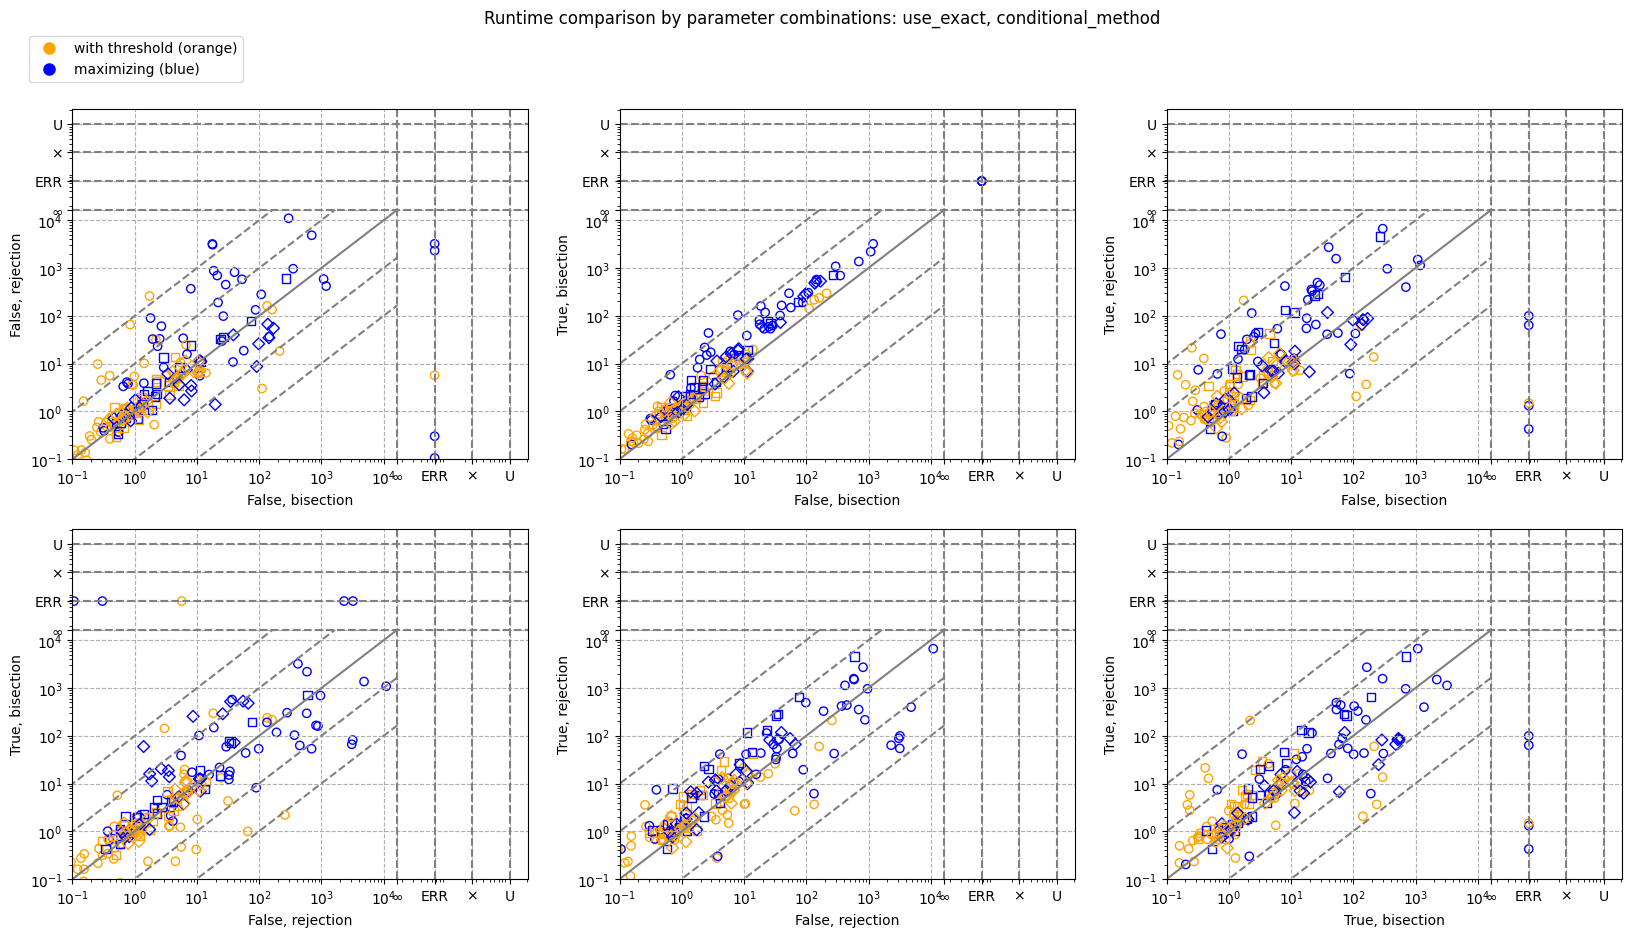

In [8]:
from matplotlib.lines import Line2D

parameters = ["use_exact", "conditional_method"]
fig, axes = compare_runtime_by_params(experiment_data, parameters, key="result")

# custom legend handles (orange = without threshold, blue = with threshold)
handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="orange",
        markerfacecolor="orange",
        markersize=8,
        linestyle="None",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="blue",
        markerfacecolor="blue",
        markersize=8,
        linestyle="None",
    ),
]
labels = ["with threshold (orange)", "maximizing (blue)"]

# make room above subplots and place a single legend above all axes, left-aligned
fig.subplots_adjust(top=0.88)
fig.legend(
    handles,
    labels,
    loc="upper left",
    bbox_to_anchor=(0.1, 0.96),
    bbox_transform=fig.transFigure,
    frameon=True,
    ncol=1,
)

Large relative difference (0.9140: times 1953 vs 168) for params (False, 'bisection') vs (False, 'rejection') in hashes ['f148f9076e1df7e3f8dbcc15d0e0ea5e', '07abc354bae51af9acabfbca408ee9de']
Large relative difference (0.9026: times 1972 vs 192) for params (False, 'bisection') vs (False, 'rejection') in hashes ['7ada4a795cb963ca806b4ef93f4e2fb7', 'f4b0be48a53a92d924e16ca7abcf12ff']
Large relative difference (0.9011: times 621106 vs 61397) for params (False, 'bisection') vs (False, 'rejection') in hashes ['55ca367198ccc2f58f7728e7d0ab441c', 'd6079fad3052de18a7ce51ceb1863b1d']
Large relative difference (0.9905: times 295063 vs 2815) for params (False, 'bisection') vs (False, 'rejection') in hashes ['cb8059ef9c0a153048c85f3d2f1114f8', 'd640f15a19041e568f7a51ad513f0a88']
Large relative difference (0.9866: times 53 vs 3970) for params (False, 'bisection') vs (False, 'rejection') in hashes ['3393821b9898bb8bd81d3b77a052727f', 'e5aa27e2bc58f3a2a86cde94eb182f68']
Large relative difference (0.

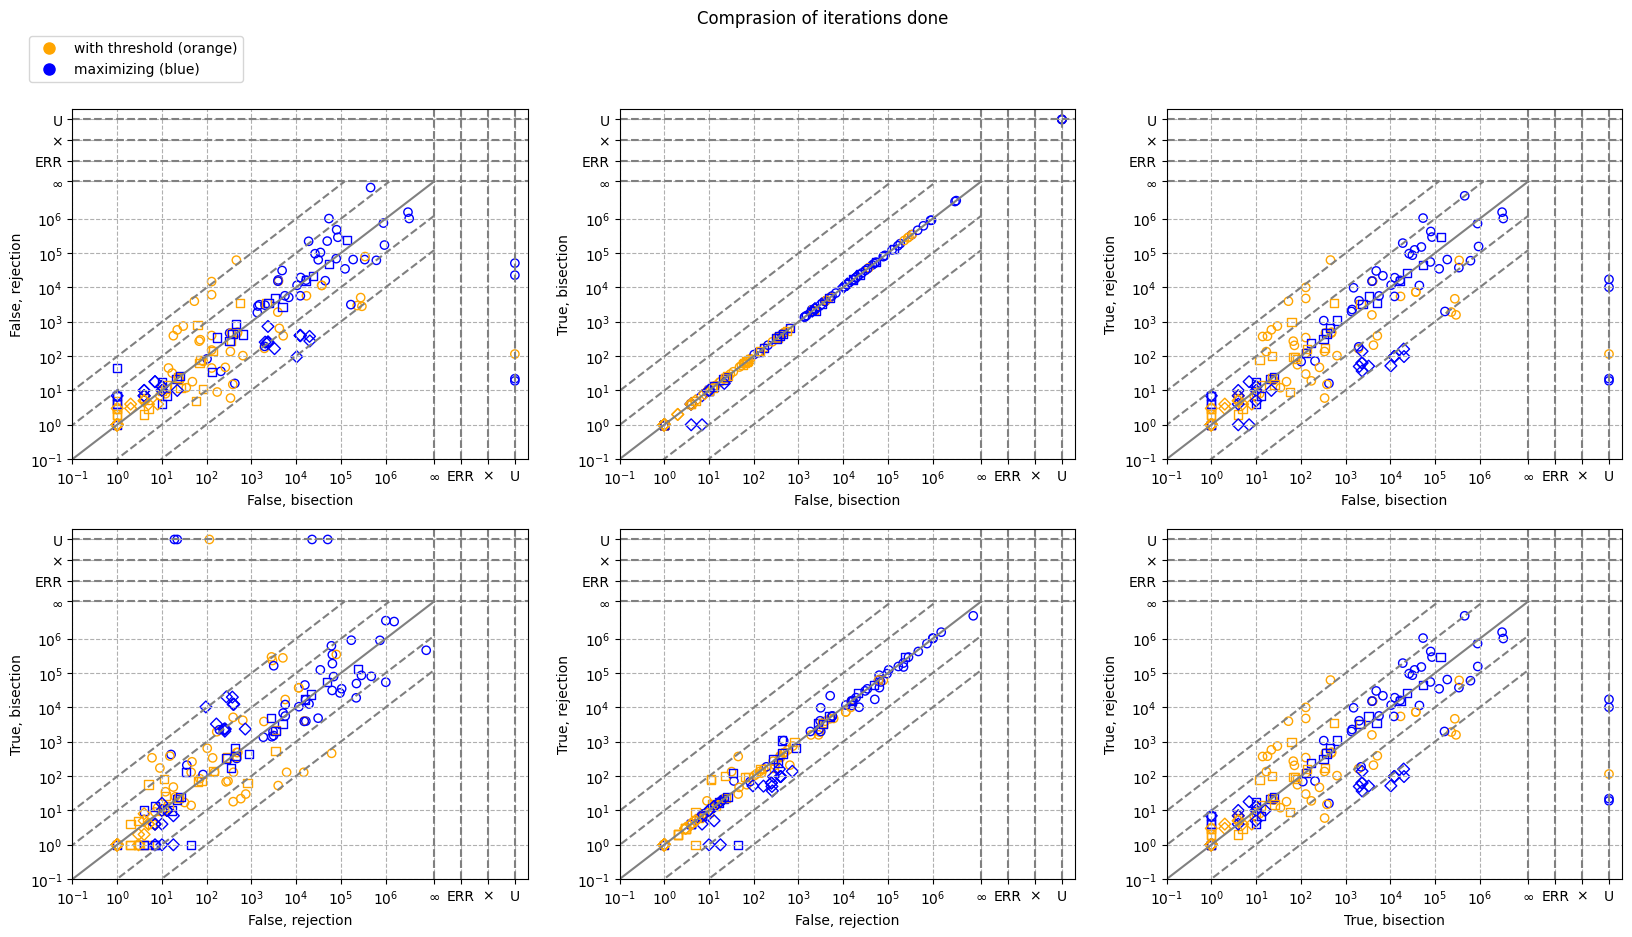

In [9]:
from matplotlib.lines import Line2D

parameters = ["use_exact", "conditional_method"]
fig, axes = compare_runtime_by_params(
    experiment_data,
    parameters,
    key="result",
    time_key="iterations",
    title="Comprasion of iterations done",
)

# custom legend handles (orange = without threshold, blue = with threshold)
handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="orange",
        markerfacecolor="orange",
        markersize=8,
        linestyle="None",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="blue",
        markerfacecolor="blue",
        markersize=8,
        linestyle="None",
    ),
]
labels = ["with threshold (orange)", "maximizing (blue)"]

# make room above subplots and place a single legend above all axes, left-aligned
fig.subplots_adjust(top=0.88)
fig.legend(
    handles,
    labels,
    loc="upper left",
    bbox_to_anchor=(0.1, 0.96),
    bbox_transform=fig.transFigure,
    frameon=True,
    ncol=1,
)

Large relative difference (2.0000: times -1 vs 1.0) for params (False, 'bisection') vs (False, 'rejection') in hashes ['8bc97314bc74e5e2b8ca1da2f4256a72', '7ef0342ad10f2595a94c8a65d861cb17']
Large relative difference (2.0000: times -1 vs 1.0) for params (False, 'bisection') vs (False, 'rejection') in hashes ['2ade5b80006795f195a61238a9b69536', '6a88a89eafd58731c00502bb5d470422']
Large relative difference (5.9414: times -1 vs 0.2023709273091236) for params (False, 'bisection') vs (False, 'rejection') in hashes ['ce5f3ed45b2ee26e0cf352249242dbcc', '7c71c94e60f67e7449d29d4acf4f01a6']
Large relative difference (2.0000: times -1 vs 1.0) for params (False, 'bisection') vs (False, 'rejection') in hashes ['0bd355af67cf95ba34be3dcfee663505', 'd9d615b85d91bdbfe53d3af8fad493c6']
Large relative difference (3.9070: times -1 vs 0.3439956614152304) for params (False, 'bisection') vs (False, 'rejection') in hashes ['71429a58198af155d6ecb86a5ef9f5c5', '43ae35ff25abab6fda462245f3d0becf']
Large relative 

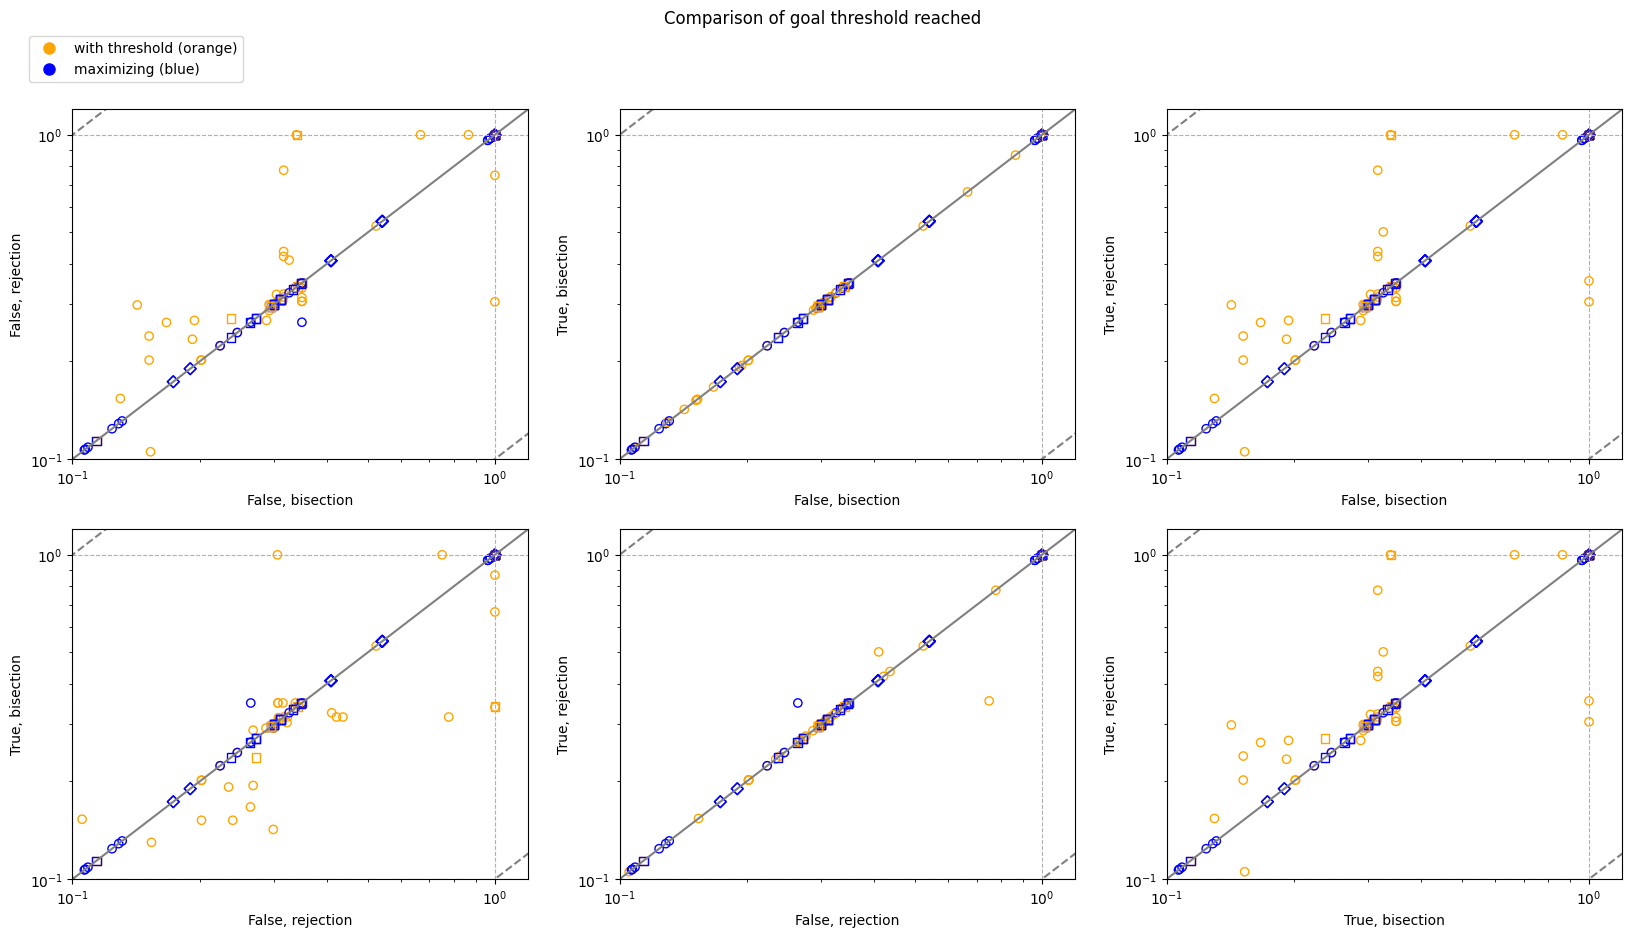

In [10]:
parameters = ["use_exact", "conditional_method"]
fig, axes = compare_runtime_by_params(
    experiment_data,
    parameters,
    key="result",
    time_key="goal_threshold",
    fit_all=False,
    title="Comparison of goal threshold reached",
)

# custom legend handles (orange = without threshold, blue = with threshold)
handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="orange",
        markerfacecolor="orange",
        markersize=8,
        linestyle="None",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="blue",
        markerfacecolor="blue",
        markersize=8,
        linestyle="None",
    ),
]
labels = ["with threshold (orange)", "maximizing (blue)"]

# make room above subplots and place a single legend above all axes, left-aligned
fig.subplots_adjust(top=0.88)
fig.legend(
    handles,
    labels,
    loc="upper left",
    bbox_to_anchor=(0.1, 0.96),
    bbox_transform=fig.transFigure,
    frameon=True,
    ncol=1,
)